**Check GPU availability and Torch version**

In [4]:
import numpy as np
import random
import time
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Torch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


**Install dependencies (first-time run)**

In [4]:
!pip install transformers datasets tiktoken wandb --upgrade
!pip install torch torchvision matplotlib --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 117.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 520.7/520.7 kB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 20.3 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 99.9 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
  ERROR: Operation cancelled by user
^C


**Clone Sophia repo (first-time run)**

In [ ]:
# !rm -rf Sophia If it displays "fatal: destination path 'Sophia' already exists", run this command.

In [1]:
!git clone https://github.com/Liuhong99/Sophia.git

fatal: destination path 'Sophia' already exists and is not an empty directory.


**Import libraries**

In [2]:
import sys
sys.path.append("/content/Sophia")
from sophia import SophiaG
from datasets import load_dataset
from transformers import GPT2Tokenizer, GPT2Config, GPT2LMHeadModel
from torch.utils.data import DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt

**Set device and training parameters**

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Adjustable parameters
BATCH_SIZE = 16
LR = 2e-4
MAX_STEPS = 1000
BLOCK_SIZE = 64

**Set random seeds for reproducibility**

In [6]:
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

**Load OpenWebText (1%)**

In [7]:
dataset = load_dataset("openwebtext", split="train[:10000]")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

plain_text/train-00000-of-00080.parquet:   0%|          | 0.00/303M [00:00<?, ?B/s]

...

plain_text/train-00076-of-00080.parquet:   0%|          | 0.00/303M [00:00<?, ?B/s]

plain_text/train-00077-of-00080.parquet:   0%|          | 0.00/303M [00:00<?, ?B/s]

plain_text/train-00078-of-00080.parquet:   0%|          | 0.00/301M [00:00<?, ?B/s]

plain_text/train-00079-of-00080.parquet:   0%|          | 0.00/303M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8013769 [00:00<?, ? examples/s]

**Tokenization**

In [8]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

def tokenize_function(example):
    return tokenizer(example["text"])

tokenized = dataset.map(tokenize_function, batched=True, remove_columns=["text"])

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1217 > 1024). Running this sequence through the model will result in indexing errors


**Create language modeling blocks**

In [9]:
def group_texts(examples):

    # Concatenate all lists in the batch
    concatenated_examples = {k: sum(examples[k], []) for k in examples.keys()}

    # Drop last tokens that don't fit a full block
    total_length = len(concatenated_examples["input_ids"])
    total_length = (total_length // BLOCK_SIZE) * BLOCK_SIZE

    # Split each column into chunks
    result = {
        k: [t[i : i + BLOCK_SIZE] for i in range(0, total_length, BLOCK_SIZE)]
        for k, t in concatenated_examples.items()
        }

    # Labels for causal LM
    result["labels"] = result["input_ids"].copy()

    return result


# Apply the grouping function to the tokenized dataset
lm_dataset = tokenized.map(
    group_texts,
    batched=True,
    remove_columns=tokenized.column_names
    )


# Split into train and validation sets
lm_dataset = lm_dataset.train_test_split(test_size=0.05, seed=SEED)

train_dataset = lm_dataset["train"]
val_dataset = lm_dataset["test"]


# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

**Define Tiny GPT model**

In [10]:
config = GPT2Config(
    vocab_size=tokenizer.vocab_size,
    n_positions=BLOCK_SIZE,
    n_embd=128,
    n_layer=2,
    n_head=2,
)

def create_model():
    return GPT2LMHeadModel(config).to(device)

**Evaluation function**

In [11]:
def evaluate(model):
    model.eval()
    total_loss = 0
    count = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = torch.tensor(batch["input_ids"]).to(device)
            labels = torch.tensor(batch["labels"]).to(device)

            outputs = model(input_ids, labels=labels)
            total_loss += outputs.loss.item()
            count += 1

    model.train()
    return total_loss / count

**Training function (Step-based, not epoch-based)**

In [12]:
def train_model(optimizer_name):
    model = create_model()

    if optimizer_name == "adamw":
        optimizer = optim.AdamW(model.parameters(), lr=LR)
    else:
        optimizer = SophiaG(
            model.parameters(),
            lr=LR,
            betas=(0.965, 0.99),
            rho=0.03,
            weight_decay=0.1,
        )

    train_losses = []
    val_losses = []

    step = 0
    start_time = time.time()

    model.train()

    while step < MAX_STEPS:
        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, labels=labels)
            loss = outputs.loss

            loss.backward()

            if optimizer_name == "adamw":
                optimizer.step()
            else:
                optimizer.step(bs=BATCH_SIZE)

            optimizer.zero_grad()

            train_losses.append(loss.item())
            step += 1

            if step % 200 == 0:
                val_loss = evaluate(model)
                val_losses.append(val_loss)
                print(f"{optimizer_name} Step {step} | Val Loss: {val_loss:.4f}")

            if step >= MAX_STEPS:
                break

    training_time = time.time() - start_time
    return train_losses, val_losses, training_time

In [13]:
def collate_fn(batch):
    # batch 是一个 list，里面每个元素是 {"input_ids": ..., "labels": ...}
    input_ids = torch.stack([torch.tensor(x["input_ids"]) for x in batch])
    labels = torch.stack([torch.tensor(x["labels"]) for x in batch])
    return {"input_ids": input_ids, "labels": labels}

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

**Train both optimizers**

In [14]:
print("Training AdamW...")
adam_train, adam_val, adam_time = train_model("adamw")  # train_loss, val_loss, training_time

print("Training SophiaG...")
sophia_train, sophia_val, sophia_time = train_model("sophia")

Training AdamW...


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
/tmp/ipykernel_690/3834684058.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids = torch.tensor(batch["input_ids"]).to(device)
/tmp/ipykernel_690/3834684058.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(batch["labels"]).to(device)


adamw Step 200 | Val Loss: 7.6052
adamw Step 400 | Val Loss: 7.2709
adamw Step 600 | Val Loss: 7.0468
adamw Step 800 | Val Loss: 6.8798
adamw Step 1000 | Val Loss: 6.7516
Training SophiaG...
sophia Step 200 | Val Loss: 7.5404
sophia Step 400 | Val Loss: 7.0562
sophia Step 600 | Val Loss: 6.8076
sophia Step 800 | Val Loss: 6.6831
sophia Step 1000 | Val Loss: 6.5821


**Plot validation loss**

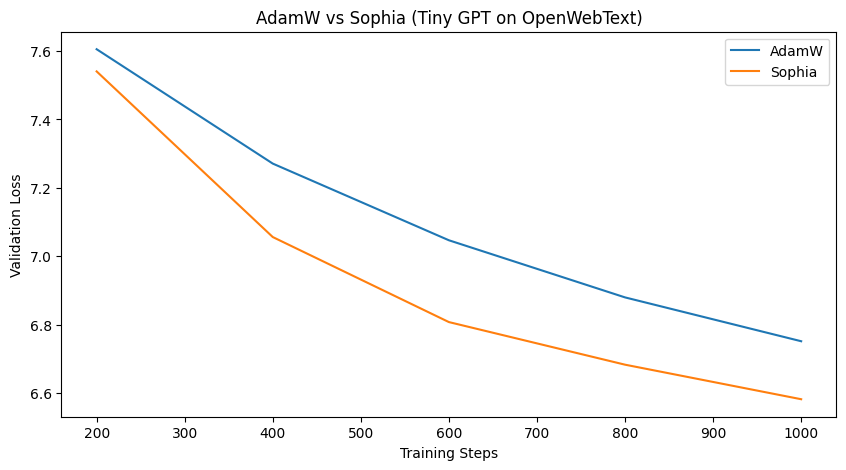

In [15]:
steps = [200*(i+1) for i in range(len(adam_val))]

plt.figure(figsize=(10,5))
plt.plot(steps, adam_val, label="AdamW")
plt.plot(steps, sophia_val, label="Sophia")
plt.xlabel("Training Steps")
plt.ylabel("Validation Loss")
plt.title("AdamW vs Sophia (Tiny GPT on OpenWebText)")
plt.legend()
plt.show()

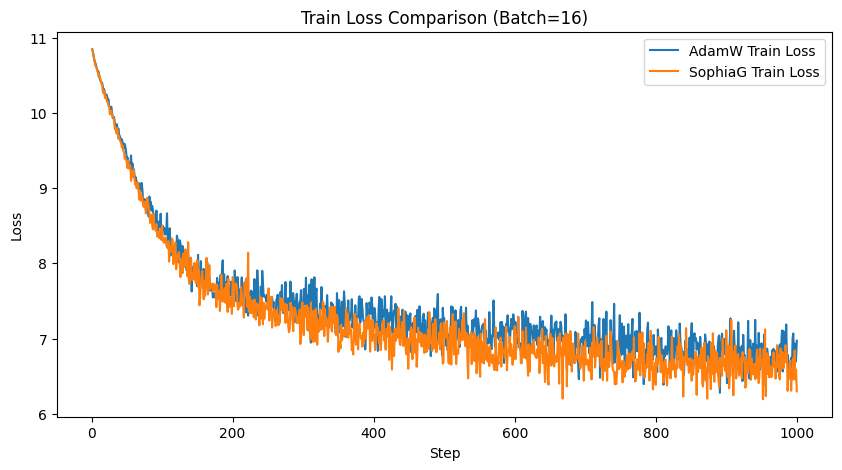

In [16]:
plt.figure(figsize=(10,5))
plt.plot(range(1, len(adam_train)+1), adam_train, label="AdamW Train Loss")
plt.plot(range(1, len(sophia_train)+1), sophia_train, label="SophiaG Train Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title(f"Train Loss Comparison (Batch={BATCH_SIZE})")
plt.legend()
plt.show()

**Experiment 2: Sophia rho sweep on OpenWebText + Tiny GPT-2**

In [17]:
# Custom SophiaG for Exp2: ensure ρ participates in clip, smaller ε
# Formula: update = clip(m_t / max(h_t, ε), -ρ, ρ), ε=1e-12 so clip still works when h is tiny
# Hessian updated every k=10 steps (controlled in training loop to reduce oscillation)
from torch.optim.optimizer import Optimizer

class SophiaG_Exp2(Optimizer):
    """SophiaG with smaller eps=1e-12 for effective clipping when h is tiny."""
    def __init__(self, params, lr=1e-4, betas=(0.965, 0.99), rho=0.04, weight_decay=1e-1, eps=1e-12):
        defaults = dict(lr=lr, betas=betas, rho=rho, weight_decay=weight_decay, eps=eps)
        super().__init__(params, defaults)

    @torch.no_grad()
    def update_hessian(self):
        for group in self.param_groups:
            beta2 = group['betas'][1]
            for p in group['params']:
                if p.grad is None:
                    continue
                state = self.state[p]
                if len(state) == 0:
                    state['step'] = torch.tensor(0.)
                    state['exp_avg'] = torch.zeros_like(p)
                    state['hessian'] = torch.zeros_like(p)
                if 'hessian' not in state:
                    state['hessian'] = torch.zeros_like(p)
                state['hessian'].mul_(beta2).addcmul_(p.grad, p.grad, value=1 - beta2)

    @torch.no_grad()
    def step(self, closure=None, bs=5120):
        for group in self.param_groups:
            rho, lr, eps = group['rho'], group['lr'], group['eps']
            beta1 = group['betas'][0]
            for p in group['params']:
                if p.grad is None:
                    continue
                state = self.state[p]
                if len(state) == 0:
                    state['step'] = torch.tensor(0.)
                    state['exp_avg'] = torch.zeros_like(p)
                    state['hessian'] = torch.zeros_like(p)
                state['step'] += 1
                exp_avg, hess = state['exp_avg'], state['hessian']
                exp_avg.mul_(beta1).add_(p.grad, alpha=1 - beta1)
                p.mul_(1 - lr * group['weight_decay'])
                # Core: update = clip(m / max(h, ε), -ρ, ρ), ρ directly participates in truncation
                denom = torch.clamp(hess, min=eps)
                ratio = (exp_avg / denom).clamp(-rho, rho)
                p.add_(ratio, alpha=-lr)
        return None

# Experiment 2 uses SophiaG_Exp2

In [18]:
# Experiment 2: use train_loader, val_loader, create_model, evaluate from Experiment 1
LOG_EVERY = 100   # Log clip proportion every N steps
EVAL_EVERY = 200  # Evaluate every N steps (same as Exp1)
HESSIAN_UPDATE_FREQ = 10  # Update Hessian every 10 steps to reduce oscillation

def set_seed(seed=42):
    """Set random seeds for reproducibility (resets for each rho run)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Same Budget metrics: Steps, Wall-clock Time, Total Compute
# TARGET_LOSS: for "Steps to Loss<=X", adjust based on actual curves (e.g. 6.8 or 7.0)
TARGET_LOSS = 7.0

In [19]:
@torch.no_grad()
def compute_clip_prop(optimizer, rho=None, bs=1, eps=1e-12):
    """Clipping proportion: SophiaG_Exp2 uses update=clip(m/max(h,ε),-ρ,ρ), so clipped when |m|/max(h,ε)>ρ."""
    total_elems = 0
    clip_elems = 0
    if rho is None:
        rho = optimizer.param_groups[0].get("rho", None)
    if rho is None:
        return None
    for p, st in optimizer.state.items():
        if not isinstance(st, dict) or "exp_avg" not in st or "hessian" not in st:
            continue
        m, h = st["exp_avg"], st["hessian"]
        if m is None or h is None or not torch.is_tensor(m) or m.numel() == 0:
            continue
        denom = torch.clamp(h, min=eps)
        ratio_raw = m.abs() / denom
        total_elems += ratio_raw.numel()
        clip_elems += (ratio_raw > rho).sum().item()
    return clip_elems / total_elems if total_elems > 0 else None


def train_adamw_baseline(seed=42, max_steps=MAX_STEPS, eval_every=EVAL_EVERY):
    """AdamW baseline with time tracking for Same Budget comparison."""
    set_seed(seed)
    model = create_model()
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.1)
    steps, val_steps, val_losses = 0, [], []
    train_iter = iter(train_loader)
    model.train()
    t0 = time.perf_counter()
    while steps < max_steps:
        try:
            batch = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            batch = next(train_iter)
        input_ids, labels = batch["input_ids"].to(device), batch["labels"].to(device)
        optimizer.zero_grad(set_to_none=True)
        outputs = model(input_ids, labels=labels)
        outputs.loss.backward()
        optimizer.step()
        steps += 1
        if steps % eval_every == 0:
            val_loss = evaluate(model)
            val_steps.append(steps)
            val_losses.append(val_loss)
    wall_time = time.perf_counter() - t0
    return {"val_steps": val_steps, "val_losses": val_losses, "wall_time": wall_time, "steps": steps}


def train_sophia_with_rho(
    rho,
    seed=42,
    max_steps=MAX_STEPS,
    log_every=LOG_EVERY,
    eval_every=EVAL_EVERY,
    hessian_freq=HESSIAN_UPDATE_FREQ,
):
    """Train with SophiaG_Exp2. Re-initialize with torch.manual_seed(seed) before each rho experiment."""
    set_seed(seed)
    model = create_model()
    optimizer = SophiaG_Exp2(
        model.parameters(),
        lr=LR,
        betas=(0.965, 0.99),
        rho=rho,
        weight_decay=0.1,
        eps=1e-12,
    )
    steps, val_steps, val_losses, clip_props = 0, [], [], []
    train_iter = iter(train_loader)
    model.train()
    t0 = time.perf_counter()
    while steps < max_steps:
        try:
            batch = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            batch = next(train_iter)
        input_ids, labels = batch["input_ids"].to(device), batch["labels"].to(device)
        optimizer.zero_grad(set_to_none=True)
        outputs = model(input_ids, labels=labels)
        outputs.loss.backward()
        if steps % hessian_freq == 0:
            optimizer.update_hessian()
        optimizer.step(bs=BATCH_SIZE)
        steps += 1
        if steps % log_every == 0:
            clip_props.append(compute_clip_prop(optimizer, rho=rho, bs=BATCH_SIZE))
        if steps % eval_every == 0:
            val_loss = evaluate(model)
            val_steps.append(steps)
            val_losses.append(val_loss)
            print(f"[rho={rho}] step {steps} | val_loss={val_loss:.4f}")
    wall_time = time.perf_counter() - t0
    return {
        "val_steps": val_steps,
        "val_losses": val_losses,
        "clip_props": clip_props,
        "wall_time": wall_time,
        "steps": steps,
    }

In [20]:
# Use more extreme ρ values for clearer curve divergence
RHO_LIST = [1e-4, 1e-3, 1e-2]
SEEDS = [42, 43, 44]  # Multi-seed average to address initialization concerns

# 1. AdamW baseline (Same Budget comparison)
print("=" * 50)
print("AdamW baseline (Same Budget)")
res_adamw = train_adamw_baseline(seed=SEED, max_steps=MAX_STEPS, eval_every=EVAL_EVERY)
print(f"AdamW: wall_time={res_adamw['wall_time']:.1f}s, final_val_loss={res_adamw['val_losses'][-1]:.4f}")

# 2. Sophia rho sweep with multi-seed average (3 seeds for robustness)
results = {}
results_multi = {rho: {"val_steps": [], "val_losses_list": [], "wall_times": [], "clip_props": None} for rho in RHO_LIST}
for seed in SEEDS:
    for rho in RHO_LIST:
        print(f"[seed={seed}] rho={rho}")
        res = train_sophia_with_rho(
            rho=rho,
            seed=seed,
            max_steps=MAX_STEPS,
            log_every=LOG_EVERY,
            eval_every=EVAL_EVERY,
            hessian_freq=HESSIAN_UPDATE_FREQ,
        )
        results_multi[rho]["val_steps"] = res["val_steps"]
        results_multi[rho]["val_losses_list"].append(res["val_losses"])
        results_multi[rho]["wall_times"].append(res["wall_time"])
        if results_multi[rho]["clip_props"] is None:
            results_multi[rho]["clip_props"] = res["clip_props"]
for rho in RHO_LIST:
    arr = np.array(results_multi[rho]["val_losses_list"])
    results[rho] = {
        "val_steps": results_multi[rho]["val_steps"],
        "val_losses": arr.mean(axis=0).tolist(),
        "val_losses_std": arr.std(axis=0).tolist(),
        "clip_props": results_multi[rho]["clip_props"],
        "wall_time": np.mean(results_multi[rho]["wall_times"]),
        "steps": MAX_STEPS,
    }

best_rho = min(RHO_LIST, key=lambda r: results[r]["val_losses"][-1] if results[r]["val_losses"] else float("inf"))
print("\nBest rho by final val_loss:", best_rho)

AdamW baseline (Same Budget)


/tmp/ipykernel_690/3834684058.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids = torch.tensor(batch["input_ids"]).to(device)
/tmp/ipykernel_690/3834684058.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(batch["labels"]).to(device)


AdamW: wall_time=53.5s, final_val_loss=6.7610
[seed=42] rho=0.0001
[rho=0.0001] step 200 | val_loss=10.8342
[rho=0.0001] step 400 | val_loss=10.8325
[rho=0.0001] step 600 | val_loss=10.8308
[rho=0.0001] step 800 | val_loss=10.8292
[rho=0.0001] step 1000 | val_loss=10.8276
[seed=42] rho=0.001
[rho=0.001] step 200 | val_loss=10.8220
[rho=0.001] step 400 | val_loss=10.8080
[rho=0.001] step 600 | val_loss=10.7940
[rho=0.001] step 800 | val_loss=10.7800
[rho=0.001] step 1000 | val_loss=10.7660
[seed=42] rho=0.01
[rho=0.01] step 200 | val_loss=10.6947
[rho=0.01] step 400 | val_loss=10.5739
[rho=0.01] step 600 | val_loss=10.4897
[rho=0.01] step 800 | val_loss=10.4213
[rho=0.01] step 1000 | val_loss=10.3538
[seed=43] rho=0.0001
[rho=0.0001] step 200 | val_loss=10.8421
[rho=0.0001] step 400 | val_loss=10.8403
[rho=0.0001] step 600 | val_loss=10.8386
[rho=0.0001] step 800 | val_loss=10.8369
[rho=0.0001] step 1000 | val_loss=10.8352
[seed=43] rho=0.001
[rho=0.001] step 200 | val_loss=10.8300
[rho

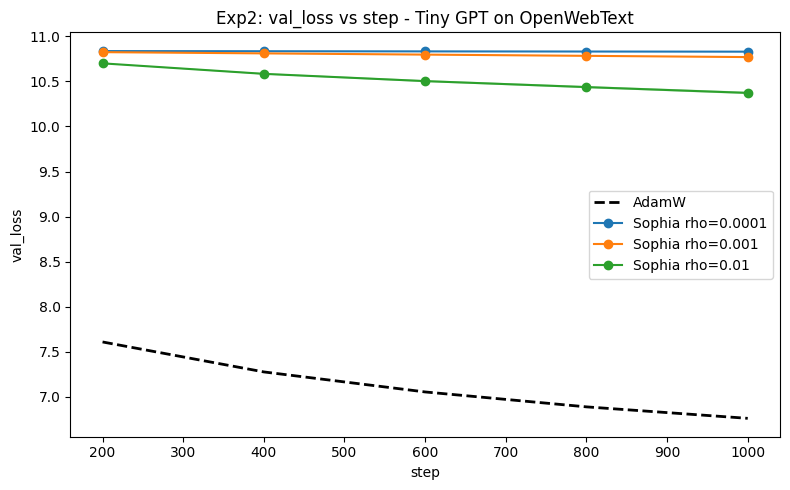

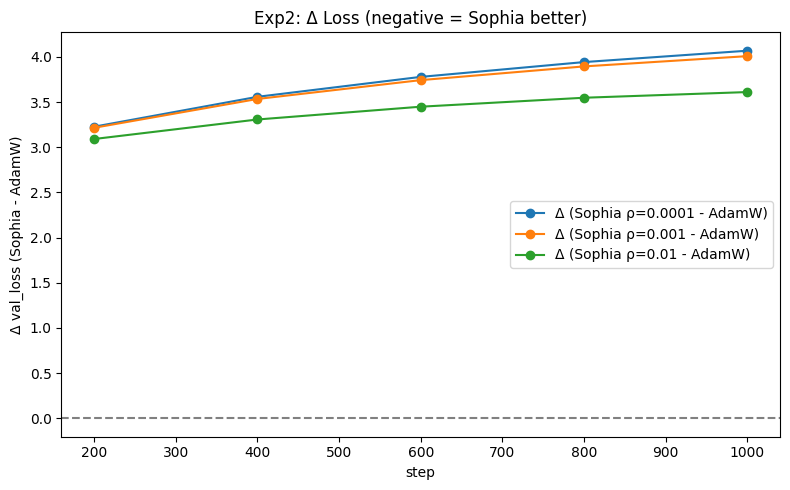

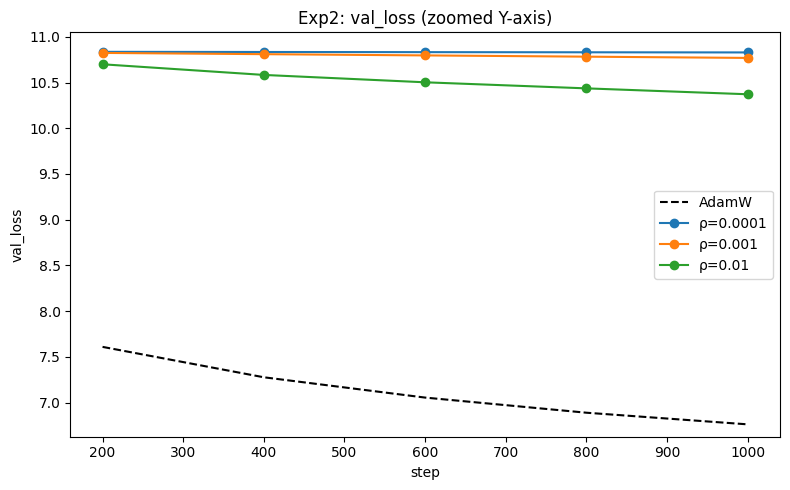

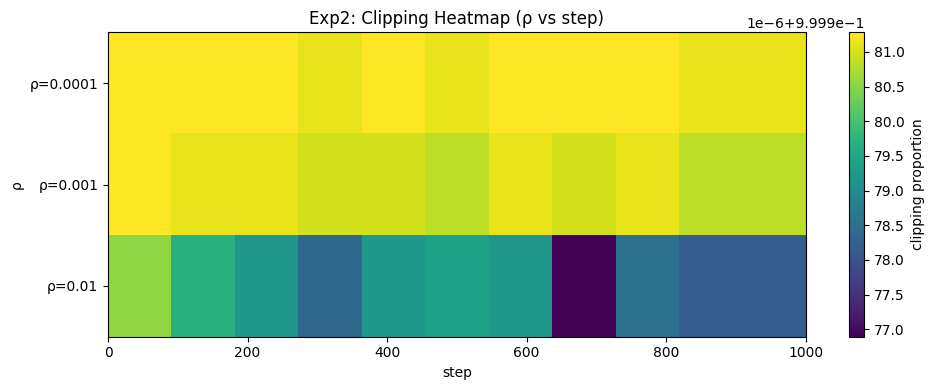

Optimizer       ρ  Final Val Loss  Steps to Loss≤X  Wall-clock Time (s) Avg Clip Prop
    AdamW     N/A        6.760994              800            53.539255            0%
  SophiaG  0.0001       10.829863             1000            55.090596       100.00%
  SophiaG   0.001       10.769800             1000            55.199474       100.00%
  SophiaG    0.01       10.372217             1000            55.337971       100.00%

Saved to exp2_summary.csv

Sophia ρ=0.0001 vs AdamW wall-time ratio (AdamW/Sophia): 0.97x

Sophia ρ=0.001 vs AdamW wall-time ratio (AdamW/Sophia): 0.97x

Sophia ρ=0.01 vs AdamW wall-time ratio (AdamW/Sophia): 0.97x


In [23]:
import pandas as pd

# Figure 1: val_loss curves (multiple rho + AdamW, with shaded std for Sophia)
plt.figure(figsize=(8, 5))
plt.plot(res_adamw["val_steps"], res_adamw["val_losses"], "k--", label="AdamW", linewidth=2)
for rho in RHO_LIST:
    st = results[rho]
    plt.plot(st["val_steps"], st["val_losses"], marker="o", label=f"Sophia rho={rho}")
    if "val_losses_std" in st and st["val_losses_std"]:
        std = np.array(st["val_losses_std"])
        plt.fill_between(st["val_steps"], np.array(st["val_losses"]) - std,
                        np.array(st["val_losses"]) + std, alpha=0.3)
plt.xlabel("step")
plt.ylabel("val_loss")
plt.title("Exp2: val_loss vs step - Tiny GPT on OpenWebText")
plt.legend()
plt.tight_layout()
plt.savefig("Exp2: val_loss vs step - Tiny GPT on OpenWebText.png", dpi=300)
plt.show()

# Figure 2: Delta Loss (loss_Sophia - loss_AdamW), <0 means Sophia is better
plt.figure(figsize=(8, 5))
adamw_steps, adamw_vals = np.array(res_adamw["val_steps"]), np.array(res_adamw["val_losses"])
for rho in RHO_LIST:
    st = results[rho]
    if len(st["val_steps"]) > 0 and len(st["val_losses"]) > 0:
        sophia_interp = np.interp(adamw_steps, st["val_steps"], st["val_losses"])
        delta = sophia_interp - adamw_vals
        plt.plot(adamw_steps, delta, marker="o", label=f"Δ (Sophia ρ={rho} - AdamW)")
plt.axhline(0, color="gray", linestyle="--")
plt.xlabel("step")
plt.ylabel("Δ val_loss (Sophia - AdamW)")
plt.title("Exp2: Δ Loss (negative = Sophia better)")
plt.legend()
plt.tight_layout()
plt.savefig("Exp2: Δ Loss (negative = Sophia better)", dpi=300)
plt.show()

# Figure 3: Narrow Y-axis to zoom in on second-half differences
plt.figure(figsize=(8, 5))
plt.plot(res_adamw["val_steps"], res_adamw["val_losses"], "k--", label="AdamW")
for rho in RHO_LIST:
    st = results[rho]
    plt.plot(st["val_steps"], st["val_losses"], marker="o", label=f"ρ={rho}")
# Zoom Y-axis: use loss range from second half of steps
cutoff = max(1, MAX_STEPS // 2)
all_vals = [v for s, v in zip(res_adamw["val_steps"], res_adamw["val_losses"]) if s >= cutoff]
for r in RHO_LIST:
    all_vals += [v for s, v in zip(results[r]["val_steps"], results[r]["val_losses"]) if s >= cutoff]
if all_vals:
    plt.ylim(min(all_vals) * 0.98, max(all_vals) * 1.02)
plt.xlabel("step")
plt.ylabel("val_loss")
plt.title("Exp2: val_loss (zoomed Y-axis)")
plt.legend()
plt.tight_layout()
plt.savefig("Exp2: val_loss (zoomed Y-axis)", dpi=300)
plt.show()

# Figure 4: Clipping Heatmap (Y-axis: rho, X-axis: step, color: clip proportion)
fig, ax = plt.subplots(figsize=(10, 4))
n_steps = MAX_STEPS // LOG_EVERY + 1
step_grid = np.arange(n_steps) * LOG_EVERY
heatmap_data = []
for rho in RHO_LIST:
    cp = results[rho]["clip_props"]
    steps_cp = np.arange(len(cp)) * LOG_EVERY if cp else np.array([0])
    vals = np.array(cp) if cp else np.array([0.0])
    row = np.interp(step_grid, steps_cp, vals) if len(vals) > 0 else np.zeros(n_steps)
    heatmap_data.append(row)
heatmap_data = np.array(heatmap_data)
if heatmap_data.size > 0:
    im = ax.imshow(heatmap_data, aspect="auto", cmap="viridis", extent=[0, MAX_STEPS, len(RHO_LIST) - 0.5, -0.5])
    ax.set_yticks(range(len(RHO_LIST)))
    ax.set_yticklabels([f"ρ={r}" for r in RHO_LIST])
    ax.set_xlabel("step")
    ax.set_ylabel("ρ")
    plt.colorbar(im, label="clipping proportion")
    plt.title("Exp2: Clipping Heatmap (ρ vs step)")
plt.tight_layout()
plt.savefig("Exp2: Clipping Heatmap (ρ vs step)", dpi=300)
plt.show()

# Summary DataFrame
def steps_to_loss(val_steps, val_losses, target):
    for s, v in zip(val_steps, val_losses):
        if v <= target:
            return s
    return val_steps[-1] if val_steps else np.nan

rows = []
rows.append({
    "Optimizer": "AdamW", "ρ": "N/A",
    "Final Val Loss": res_adamw["val_losses"][-1] if res_adamw["val_losses"] else np.nan,
    "Steps to Loss≤X": steps_to_loss(res_adamw["val_steps"], res_adamw["val_losses"], TARGET_LOSS),
    "Wall-clock Time (s)": res_adamw["wall_time"],
    "Avg Clip Prop": "0%",
})
for rho in RHO_LIST:
    st = results[rho]
    cp = [c for c in st["clip_props"] if c is not None]
    mean_clip = np.mean(cp) * 100 if cp else np.nan
    rows.append({
        "Optimizer": "SophiaG", "ρ": rho,
        "Final Val Loss": st["val_losses"][-1] if st["val_losses"] else np.nan,
        "Steps to Loss≤X": steps_to_loss(st["val_steps"], st["val_losses"], TARGET_LOSS),
        "Wall-clock Time (s)": st["wall_time"],
        "Avg Clip Prop": f"{mean_clip:.2f}%",
    })
df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv("exp2_summary.csv", index=False)
print("\nSaved to exp2_summary.csv")

# Speedup ratio (time to reach same Loss)
adamw_time = res_adamw["wall_time"]
for rho in RHO_LIST:
    st = results[rho]
    # Simplified: use wall_time ratio
    if st["val_losses"] and res_adamw["val_losses"]:
        ratio = adamw_time / st["wall_time"] if st["wall_time"] > 0 else np.nan
        print(f"\nSophia ρ={rho} vs AdamW wall-time ratio (AdamW/Sophia): {ratio:.2f}x")

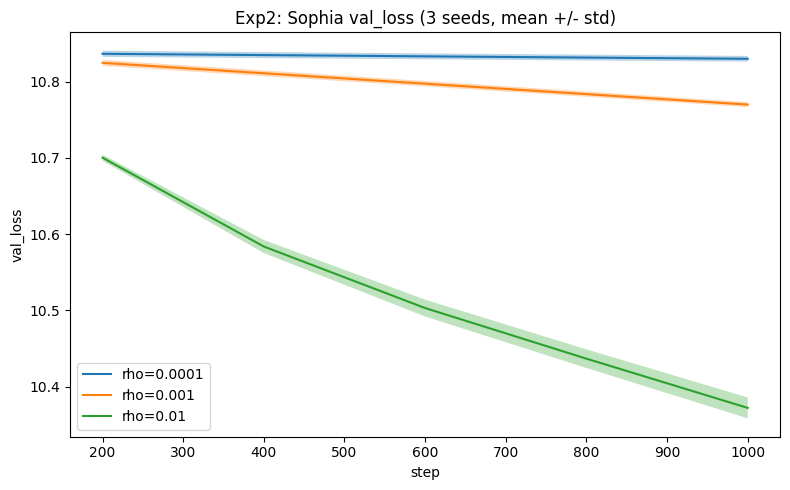

In [27]:
# Peer Review Response: Multi-seed loss curves with shaded std (addresses "Outcome flip" / initialization concern)
plt.figure(figsize=(8, 5))
for rho in RHO_LIST:
    arr = np.array(results_multi[rho]["val_losses_list"])
    mean, std = arr.mean(axis=0), arr.std(axis=0)
    plt.fill_between(results_multi[rho]["val_steps"], mean - std, mean + std, alpha=0.3)
    plt.plot(results_multi[rho]["val_steps"], mean, label=f"rho={rho}")
plt.xlabel("step")
plt.ylabel("val_loss")
plt.title("Exp2: Sophia val_loss (3 seeds, mean +/- std)")
plt.legend()
plt.tight_layout()
plt.savefig("Exp2_Sophia_val_loss_3seeds_mean_std.png", dpi=300)
plt.show()